In [ ]:
import torch
import torch.nn as nn
import torchsde
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import lightning as pl
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

from control.contoller import OptimalRoute
from control.neuralsde import MLPSDE,SDEWrapper
from control.data import TimeSeriesDataset
from control.training import SDELightningModule, SDEWrapper
from control.contoller import StepController
from control.model import LinearControlSDE

In [3]:
best_model_path = "checkpoints/sde-epoch=09-val_loss=0.0011.ckpt"
batch_size = 1
num_workers = 1
state_size = 2
control_size = 1
wlen_train = 10
hidden_size = 32
hidden_layers = 1
lr = 1e-3
method = "euler"
dt = 1e-2

In [4]:
model = SDELightningModule.load_from_checkpoint(
    best_model_path,
    #state_size, control_size, hidden_size, hidden_layers, controller_type='step', lr=lr, method=method, dt=dt
)

In [5]:
T = 20
N = 100
dt = T/(N+1)

In [6]:
x0 = torch.tensor([[1.,1.]])
x_target = torch.tensor([[2.,2.]])
ts = torch.linspace(0, T, N).unsqueeze(0)
u = nn.Parameter(torch.ones((1, 100, 1)), requires_grad=True)

In [7]:
model.train()

SDELightningModule(
  (sde_wrapper): SDEWrapper(
    (sde): MLPSDE(
      (control_input): StepController()
      (drift): Sequential(
        (0): Linear(in_features=3, out_features=32, bias=True)
        (1): Tanh()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): Tanh()
        (4): Linear(in_features=32, out_features=2, bias=True)
      )
    )
  )
)

In [8]:
def sim_cost(u):
    u_squared = (u ** 2).sum(dim=-1)  # Shape: (batch, time_steps)
    return torch.sum((u_squared[:, :-1] + u_squared[:, 1:]) / 2 * dt, dim=1)

def loss(result, u):
    l1 = nn.functional.mse_loss(result[-1], x_target)
    l2 = sim_cost(u)
    return l1,l2

In [23]:
optimizer = torch.optim.Adam([u], lr=0.1)
pbar = tqdm(range(100))
for _ in pbar:
    optimizer.zero_grad()
    l1, l2 = loss(model(x0, ts, u).transpose(1,0), u)
    l = l1 + 0.01*l2
    l.backward()
    optimizer.step()
    pbar.set_postfix({'l1': f'{l1.item():.3f}', 'l2': f'{l2.item():.3f}'})

100%|██████████| 100/100 [02:23<00:00,  1.44s/it, l1=0.002, l2=7.691]


In [24]:
with torch.no_grad():
    ys = model(x0, ts, u).transpose(1,0)

In [25]:
m, k, c = 1.0, 1.0, 0.5
A = torch.tensor([[0.0, 1.0],[-k/m, -c/m]])
B = torch.tensor([[0.0], [1.0/m]])

In [26]:
control_input = OptimalRoute(A, B, x_target, T=T)
sde = LinearControlSDE(A, B, control_input=control_input, sigma=0.0)
sde = torch.compile(sde)

# Simulate multiple trajectories
ys_opt = torchsde.sdeint(sde, x0, ts[0], method="euler", dt_min=1e-1)

In [27]:
print("Real optimized cost: ", control_input.cost(x0).item())
print("Simulated optimized cost: ", sim_cost(u).item())

Real optimized cost:  7.956830978393555
Simulated optimized cost:  7.694311141967773


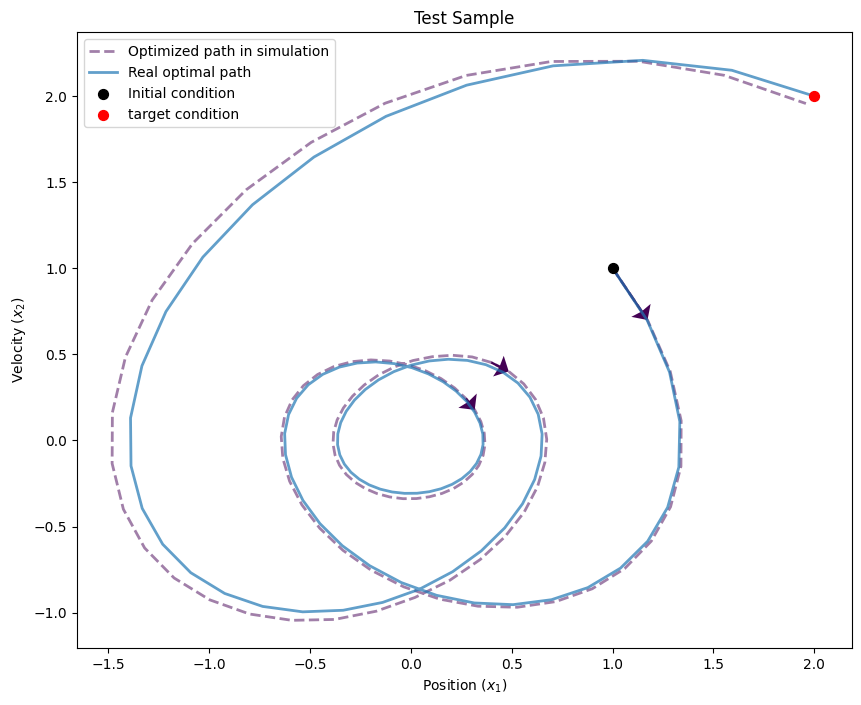

In [30]:
ts_np = ts[0].detach().numpy()
ys_np = ys.detach().numpy()
ys_np_opt = ys_opt.detach().numpy()
#xs_np = x.transpose(1,0).detach().numpy()

# Phase portrait
plt.figure(figsize=(10, 8))
num = 4
# Create a grid for the vector field
x1_range = np.linspace(ys_np[:, :, 0].min(), ys_np[:, :, 0].max()+0.01, 100)
x2_range = np.linspace(ys_np[:, :, 1].min(), ys_np[:, :, 1].max(), 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Plot trajectories
colors = plt.cm.viridis(np.linspace(0, 1, num))
for i in range(batch_size):
    if i>=num: break
    plt.plot(ys_np[:,i,0], ys_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i], linestyle='--', label="Optimized path in simulation")
    #plt.plot(xs_np[:,i,0], xs_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i])

    arrow_idx = np.arange(0, len(ys_np)-1, len(ys_np)//3)
    plt.quiver(ys_np[arrow_idx,i, 0], ys_np[arrow_idx,i, 1],
               ys_np[arrow_idx+1,i, 0] - ys_np[arrow_idx,i, 0],
               ys_np[arrow_idx+1,i, 1] - ys_np[arrow_idx,i, 1],
               color=colors[i], scale_units='xy', angles='xy', scale=1, width=0.003, headwidth=10)

plt.plot(ys_np_opt[:, i, 0], ys_np_opt[:, i, 1], alpha=0.7, linewidth=2, label=f'Real optimal path')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linewidth=2, linestyle='--', label='Simulation'),
    Line2D([0], [0], color='gray', linewidth=2, linestyle='-', label='Real')
]
plt.scatter(x0[:,0].numpy(), x0[:,1].numpy(), s=50, c="k", zorder=5, label='Initial condition')
plt.scatter(x_target[0,0].numpy(), x_target[0,1].numpy(), s=50, c="red", zorder=5, label='target condition')
plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Test Sample')
plt.legend(loc='upper left')
plt.savefig('images/phase_portrait_test_optim.png', dpi=300, bbox_inches='tight')
plt.show()